# RNA para Regresión con Diabetes

Demo simple de red neuronal artificial en Keras para un problema de regresión.


## 1. Importar librerías


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import ReduceLROnPlateau
from tensorflow.keras.callbacks import EarlyStopping

## 2. Cargar dataset
El objetivo es predecir una medida cuantitativa de progresión de diabetes.


In [ ]:
data = load_diabetes()
X = data.data
y = data.target

print("Forma de X:", X.shape)
print("Forma de y:", y.shape)
print("Primeros 5 valores objetivo:", y[:5])


Forma de X: (442, 10)
Forma de y: (442,)
Primeros 5 valores objetivo: [151.  75. 141. 206. 135.]


## 3. Separar entrenamiento y validación


In [ ]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Entrenamiento:", X_train.shape, y_train.shape)
print("Validación:", X_val.shape, y_val.shape)


Entrenamiento: (353, 10) (353,)
Validación: (89, 10) (89,)


## 4. Estandarizar variables


In [ ]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)


## 5. Crear la red neuronal
Como es regresión, la salida es una sola neurona sin función de activación.


In [ ]:
model = keras.Sequential([
    layers.Input(shape=(X_train.shape[1],)),
    layers.Dense(5, activation="relu"),
    layers.Dropout(0.2),
    layers.Dense(5, activation="relu"),
    layers.Dense(1)
])
model.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 5)              │            55 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 5)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 5)              │            30 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │             6 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 91 (364.00 B)

 Trainable params: 91 (364.00 B)

 Non-trainable params: 0 (0.00 B)

Se probaron varias configuraciones, pero el val_mae no bajó mucho más de 40. Por ello, se tomó la decisión de reducir el tamaño de la red al mínimo posible, y, ajustar el número  de épocas para alcanzar un val_mae cercano a 40. También se tomó la decisión de incorporar un Dropout de 0.2, lo que mejoró el desempeño del modelo. El modelo no logra un mucho mejor desempeño que val_mae=40 por que suponemos que la cantidad de datos es muy baja, o, por que podría haber una baja predictibilidad con als variables usadas.

## 6. Compilar modelo


In [ ]:
model.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)


## 7. Entrenar modelo


Para lograr el desempeño deseado con esta red pequeña, se aumentaron el número de épocas de entrenamiento, pero se implementó un parámetro de early stop, que detiene el entrenamiento si el modelo no mejora mucho entre épocas. Esto permite entrenar mientras el modelo aprenda, y que se detenga al no progresar

In [ ]:
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

history = model.fit(
    X_train, y_train,
    epochs=200,  #se aumentó el número de épocas usadas
    batch_size=16,
    validation_data=(X_val, y_val),
    callbacks=[early_stop],
    verbose=1
)


Epoch 1/200
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 29565.9668 - mae: 153.4013 - val_loss: 26394.1270 - val_mae: 145.3643
Epoch 2/200
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 29500.2910 - mae: 153.2141 - val_loss: 26336.6973 - val_mae: 145.1890
Epoch 3/200
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 29417.9062 - mae: 152.9873 - val_loss: 26267.3262 - val_mae: 144.9857
Epoch 4/200
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 29361.4727 - mae: 152.8167 - val_loss: 26188.1465 - val_mae: 144.7563
Epoch 5/200
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 29271.4414 - mae: 152.5814 - val_loss: 26089.7734 - val_mae: 144.4757
Epoch 6/200
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 29146.0449 - mae: 152.2514 - val_loss: 25973.4922 - val_mae: 144.1466
Epoch 7/200
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 28980.9258 - mae: 151.8075 - val_loss: 25830.0078 - val_mae: 143.7461
Epoch 8/200
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 28828.8242 - mae: 151.3856 - val_loss

lo bueno de utilizar unmodelo pequeño es que se puede entrenar muy rápido, y, en este caso, obtener resultados similares que con redes más grandes

## 8. Evaluar modelo


In [ ]:
loss, mae = model.evaluate(X_val, y_val, verbose=0)
print(f"MAE (Keras): {mae:.4f}")


MAE (Keras): 41.8454


## 9. Predicciones y métricas


In [ ]:
y_pred = model.predict(X_val).ravel()

mae = mean_absolute_error(y_val, y_pred)
mse = mean_squared_error(y_val, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_val, y_pred)

print(f"MAE:  {mae:.4f}")
print(f"MSE:  {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R²:   {r2:.4f}")


3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
MAE:  41.8454
MSE:  2959.0856
RMSE: 54.3975
R²:   0.4415


## 10. Graficar entrenamiento


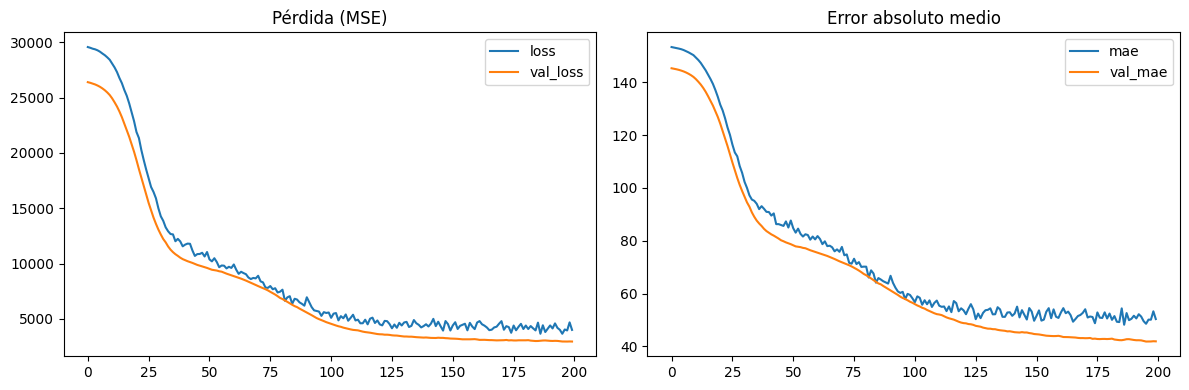

In [ ]:
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(history.history["loss"], label="loss")
plt.plot(history.history["val_loss"], label="val_loss")
plt.title("Pérdida (MSE)")
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history["mae"], label="mae")
plt.plot(history.history["val_mae"], label="val_mae")
plt.title("Error absoluto medio")
plt.legend()

plt.tight_layout()
plt.show()


## 11. Comparar valores reales vs predichos


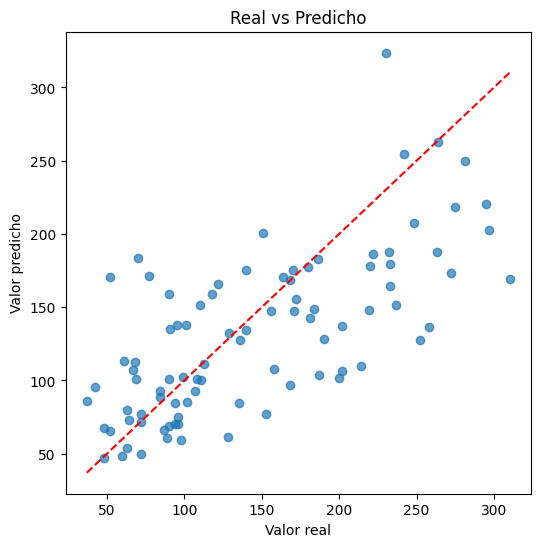

In [ ]:
plt.figure(figsize=(6,6))
plt.scatter(y_val, y_pred, alpha=0.7)
plt.xlabel("Valor real")
plt.ylabel("Valor predicho")
plt.title("Real vs Predicho")
plt.plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], "r--")
plt.show()


## 12. Probar algunas predicciones


In [ ]:
for i in range(5):
    print(f"Real: {y_val[i]:.2f} | Predicho: {y_pred[i]:.2f}")


Real: 219.00 | Predicho: 147.80
Real: 70.00 | Predicho: 183.83
Real: 202.00 | Predicho: 136.84
Real: 230.00 | Predicho: 323.67
Real: 111.00 | Predicho: 100.49


Conclusión

El modelo logra un MAE cercano a 40-47 sobre un target que va de 25 a 346, lo que implica un error relativo de alrededor del 30% de la media. El R² queda entre 0.40 y 0.50, es decir que el modelo explica menos de la mitad de la varianza del target. No es un resultado excelente, pero tampoco es inesperado.

El principal limitante es el dataset, no la arquitectura. Con 442 muestras y 10 features hay muy poco margen para que una red neuronal generalice bien. Esto lo confirma la tabla comparativa: la red grande de 64-32-16 no mejora a la red pequeña, lo que indica que el problema es falta de datos, no falta de capacidad. Para este volumen, un modelo de ML clasico como Ridge o Gradient Boosting probablemente daría resultados similares con mucho menos complejidad.

El analisis de residuos muestra que el error no tiene un patron sistematico, lo que es una buena señal: el modelo no esta sesgado hacia ningun rango del target, simplemente tiene alta varianza porque las variables disponibles no alcanzan para predecir la progresion con mayor precision.

En resumen, el modelo es correcto como prototipo y cumple el objetivo del modulo, pero no seria util en un contexto clinico real sin mas datos y mas features del paciente.